In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [ ]:
df = pd.read_csv("../Dataset/cleaned_dataset.csv")

In [ ]:
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [ ]:
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [ ]:
df.shape

(10324, 33)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Numerical columns
df.select_dtypes(include=np.number).columns

Index(['ID', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price',
       'Line Item Insurance (USD)'],
      dtype='object')

In [ ]:
#Categorical columns
df.select_dtypes(include="object").columns

Index(['Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Manufacturing Site', 'First Line Designation',
       'Weight (Kilograms)', 'Freight Cost (USD)'],
      dtype='object')

In [ ]:
#Value Counts of Every Categorical Column
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("="*50)
    print(col)
    print(df[col].value_counts())
    print()

Project Code
Project Code
116-ZA-T30    768
104-CI-T30    729
151-NG-T30    628
114-UG-T30    596
108-VN-T30    522
             ... 
103-CD-T30      1
A01-SN-T50      1
100-BZ-T30      1
900-GY-T30      1
104-SZ-T30      1
Name: count, Length: 142, dtype: int64

PQ #
PQ #
Pre-PQ Process    2681
FPQ-14942          205
FPQ-12522          154
FPQ-13973          110
FPQ-4537            98
                  ... 
FPQ-15448            1
FPQ-13457            1
FPQ-14064            1
FPQ-13316            1
FPQ-11727            1
Name: count, Length: 1237, dtype: int64

PO / SO #
PO / SO #
SCMS-199289    67
SCMS-199283    63
SCMS-183950    55
SCMS-215370    38
SCMS-259075    38
               ..
SCMS-230        1
SCMS-274        1
SCMS-308        1
SCMS-354        1
SCMS-488        1
Name: count, Length: 6233, dtype: int64

ASN/DN #
ASN/DN #
ASN-19166    54
ASN-24415    38
ASN-23875    26
ASN-32138    19
ASN-28033    17
             ..
DN-3716       1
DN-3772       1
DN-3880       1
DN-3788    

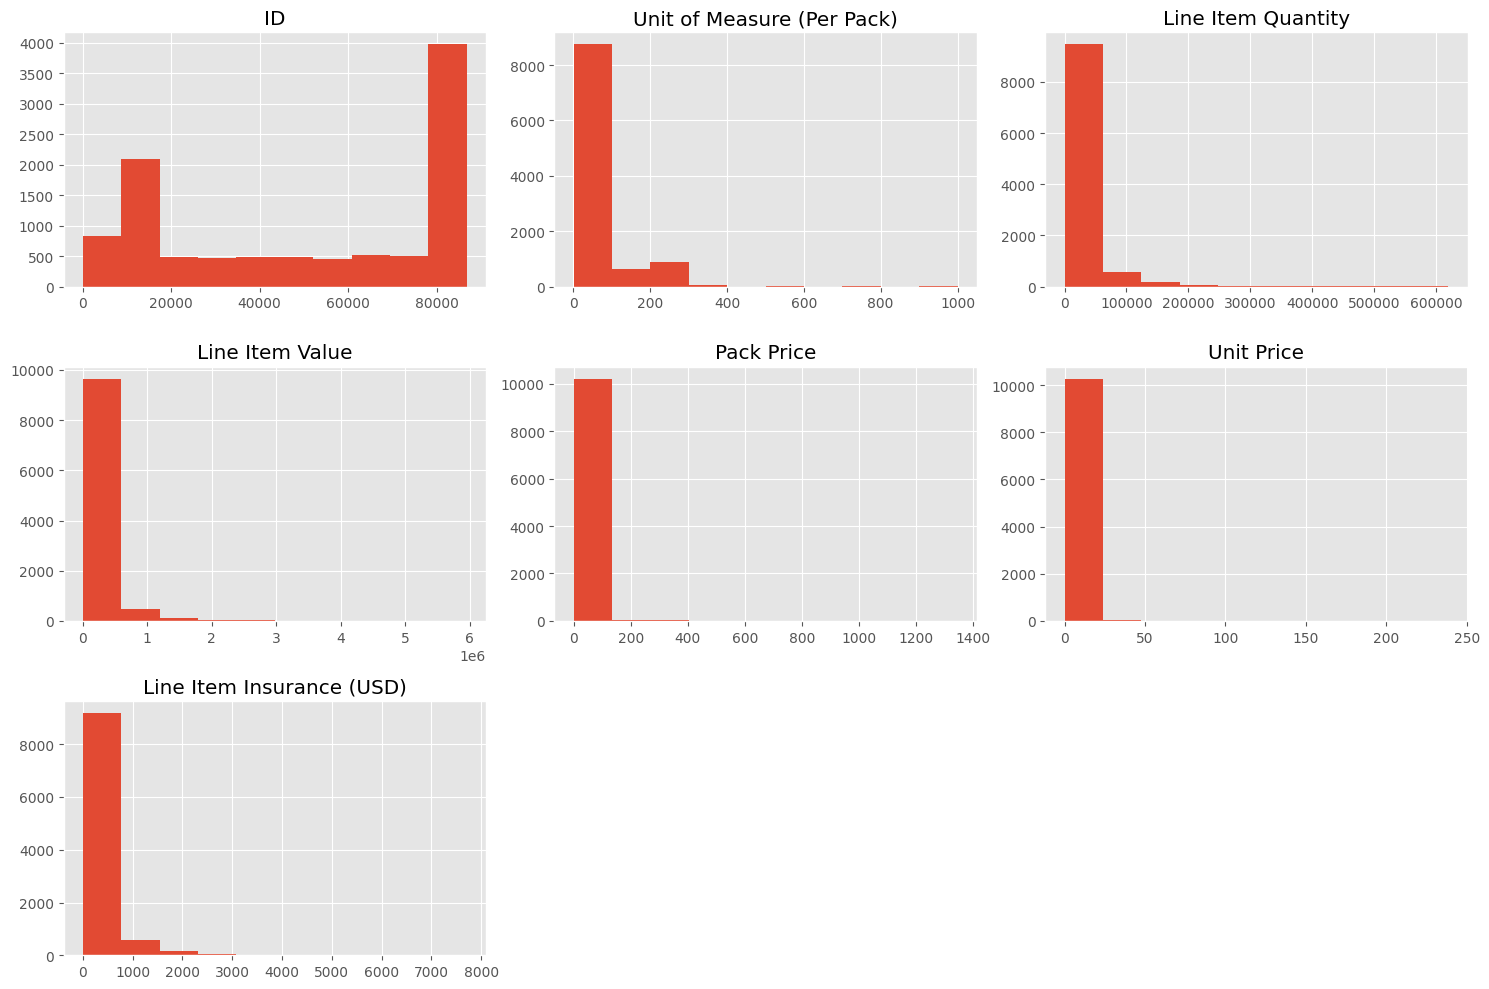

In [ ]:
#Histograms for Numerical Columns
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

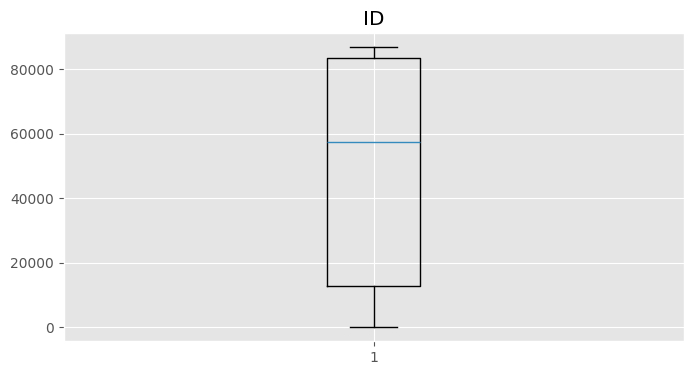

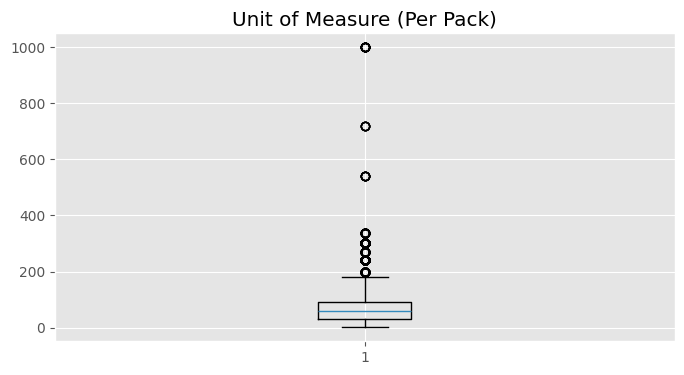

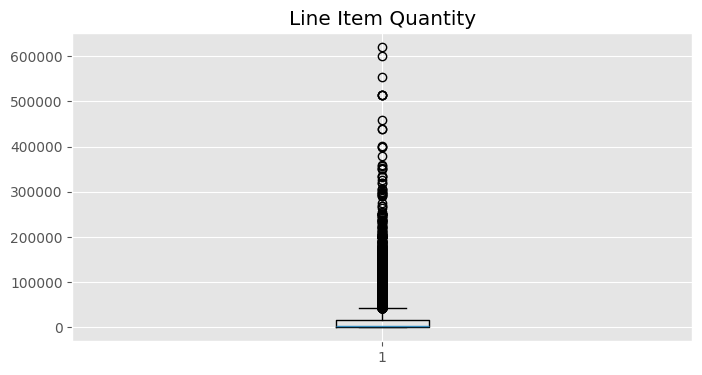

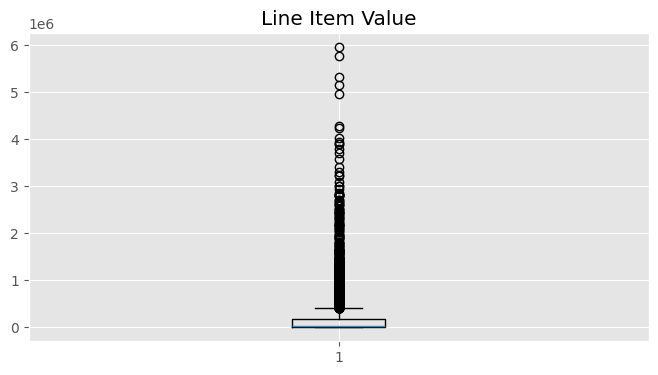

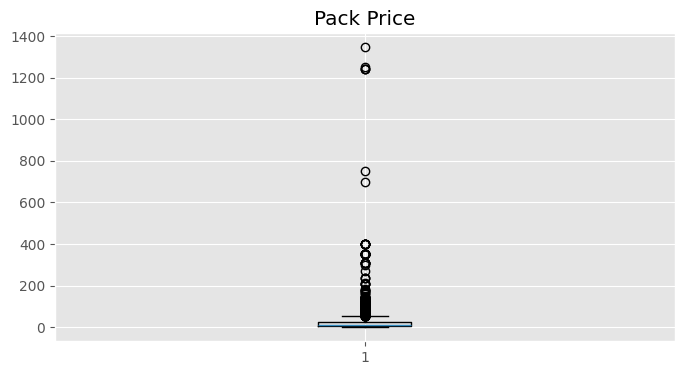

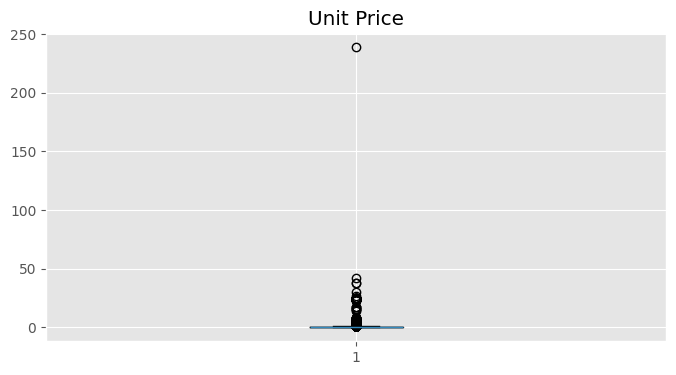

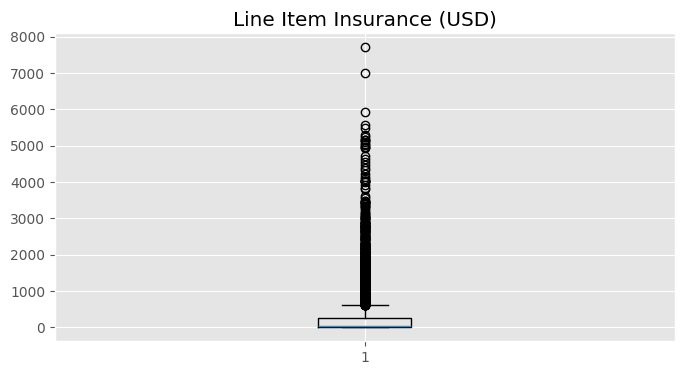

In [ ]:
#Boxplots for Numerical Columns
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    plt.figure(figsize=(8,4))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

In [ ]:
#Correlation Matrix
correlation = df.corr(numeric_only=True)

correlation

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
ID,1.000000,-0.083356,0.192006,0.136335,-0.168745,-0.073268,0.103557
Unit of Measure (Per Pack),-0.083356,1.000000,-0.151020,-0.128666,0.097182,-0.102806,-0.131825
Line Item Quantity,0.192006,-0.151020,1.000000,0.839081,-0.133651,-0.052227,0.798662
Line Item Value,0.136335,-0.128666,0.839081,1.000000,-0.018809,-0.019583,0.961353
Pack Price,-0.168745,0.097182,-0.133651,-0.018809,1.000000,0.250043,-0.015398
Unit Price,-0.073268,-0.102806,-0.052227,-0.019583,0.250043,1.000000,-0.021433
Line Item Insurance (USD),0.103557,-0.131825,0.798662,0.961353,-0.015398,-0.021433,1.000000


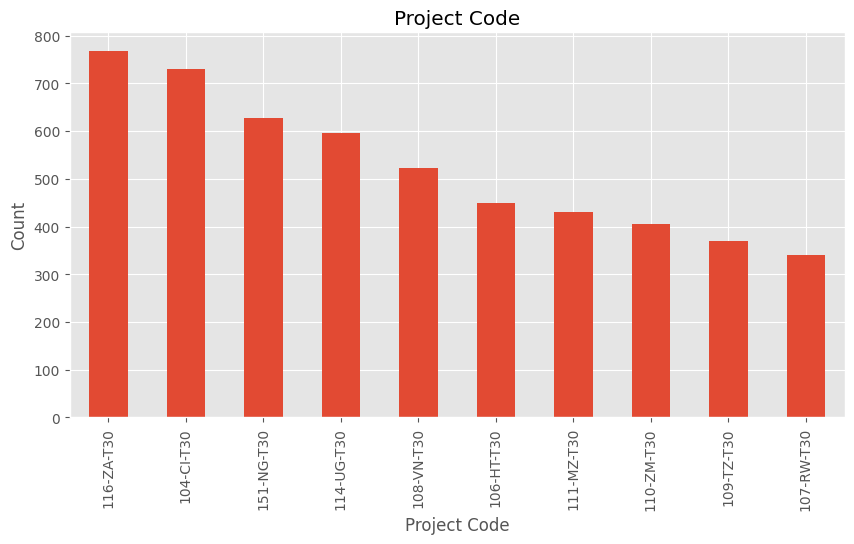

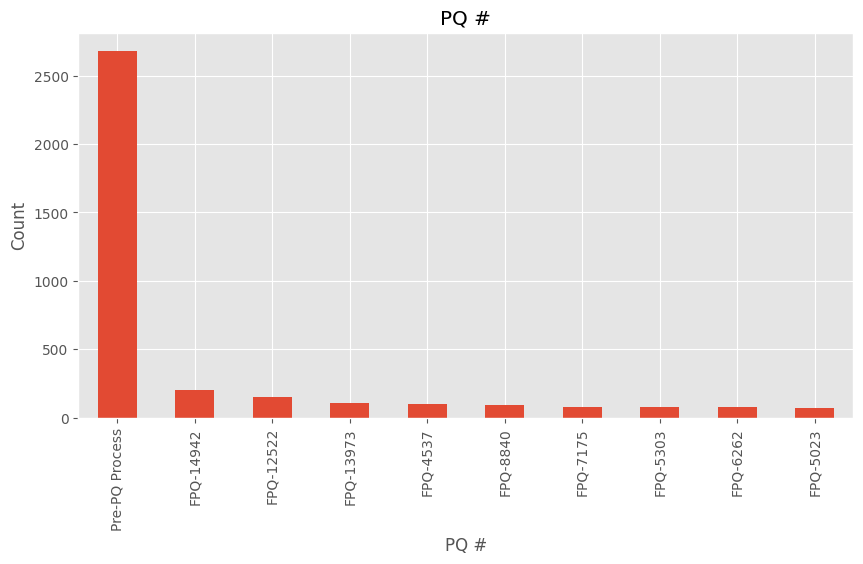

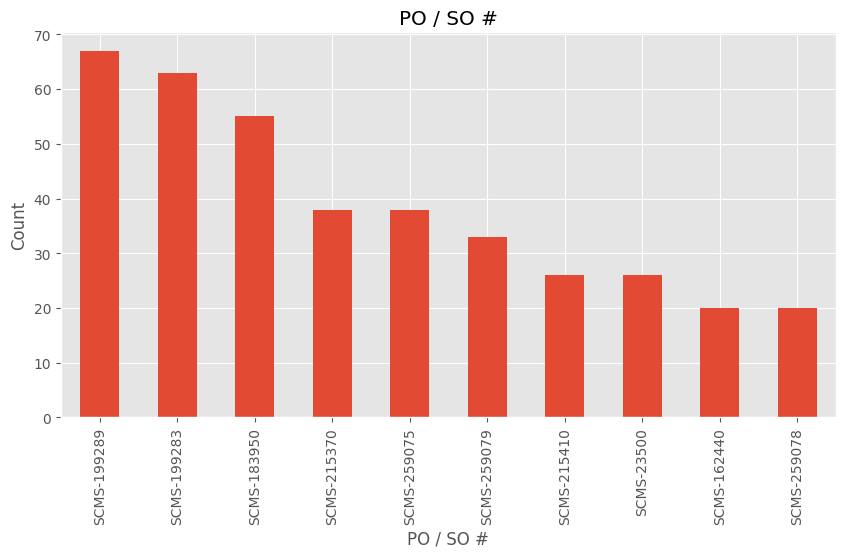

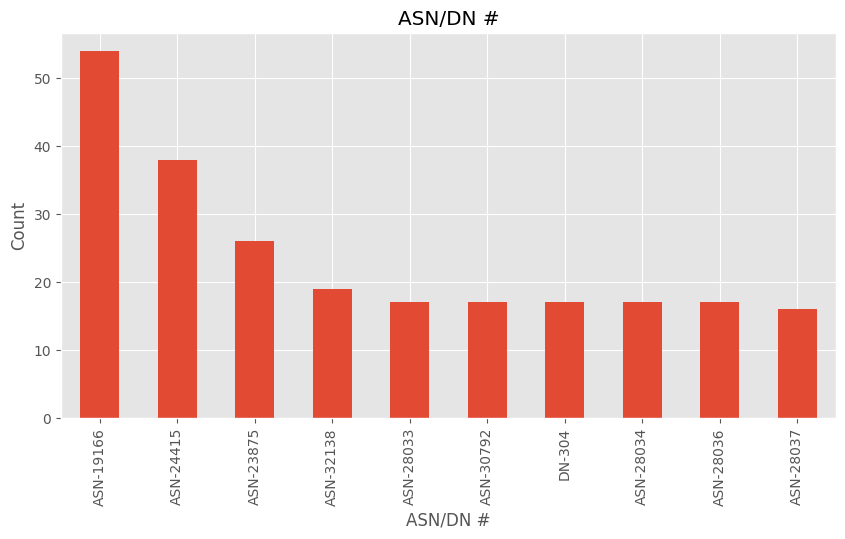

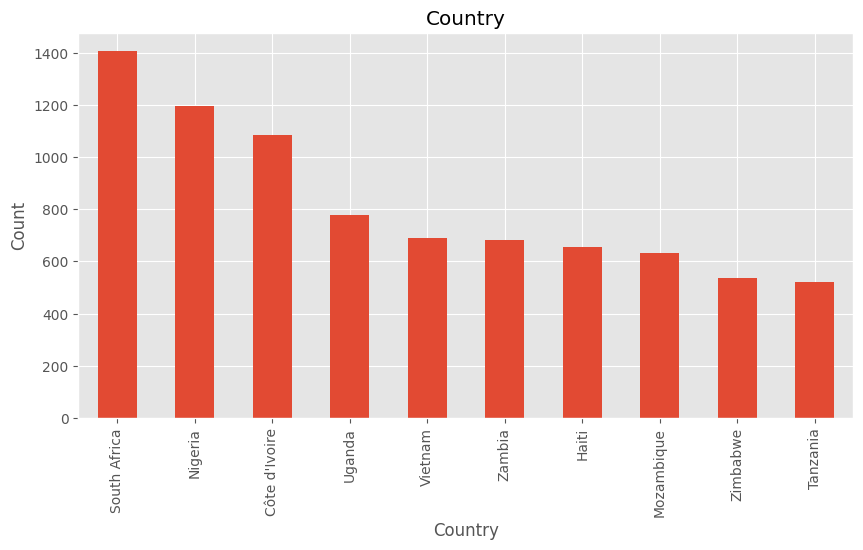

In [ ]:

#Bar Charts for Important Categorical Columns

for col in categorical_columns[:5]:

    plt.figure(figsize=(10,5))

    df[col].value_counts().head(10).plot(kind="bar")

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Count")

    plt.show()

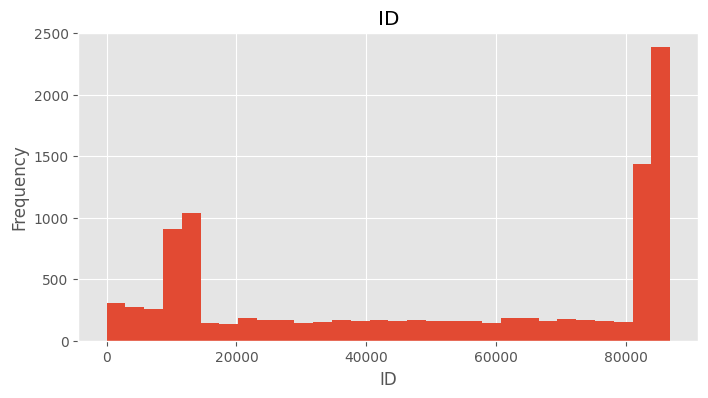

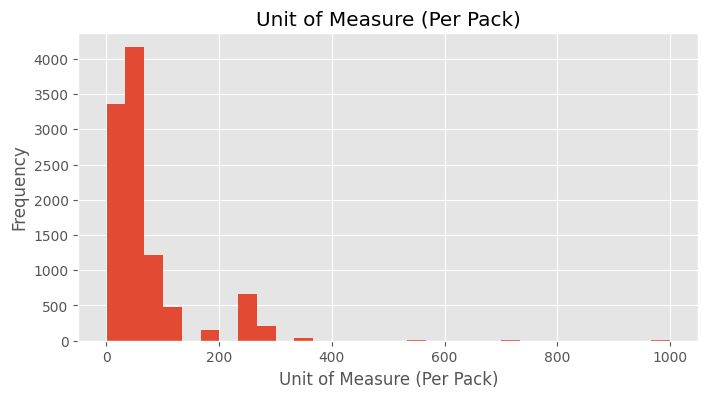

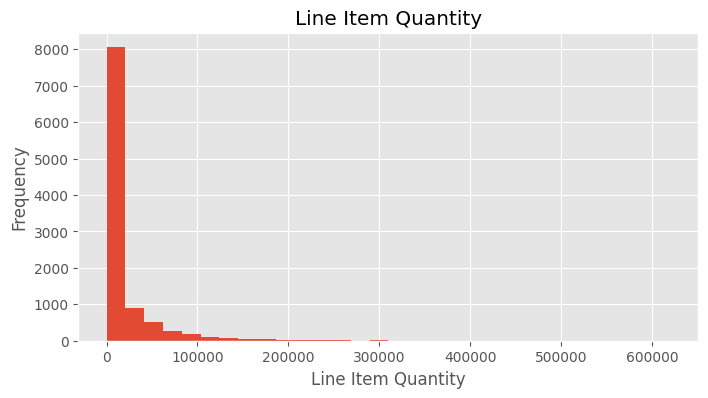

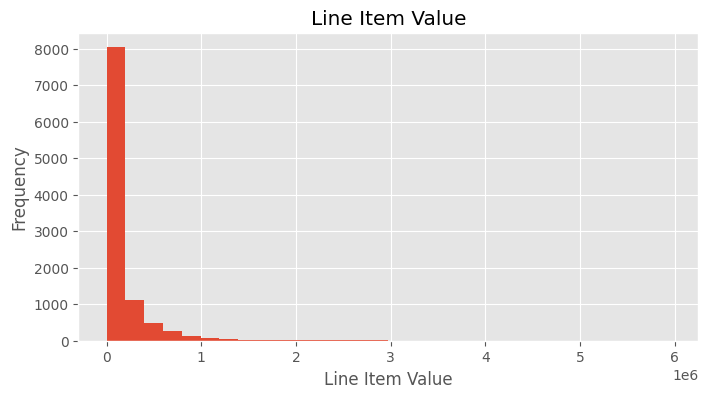

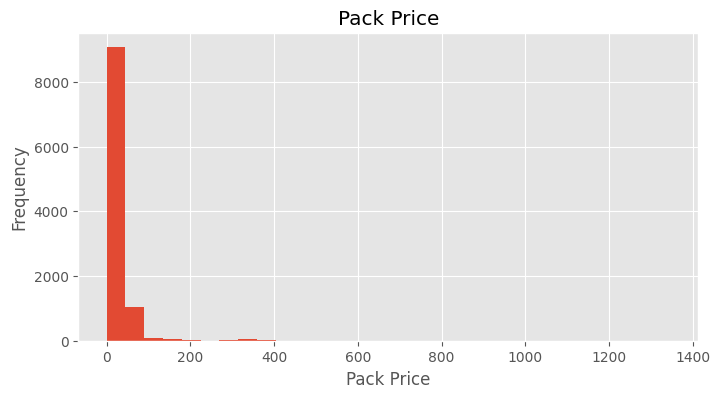

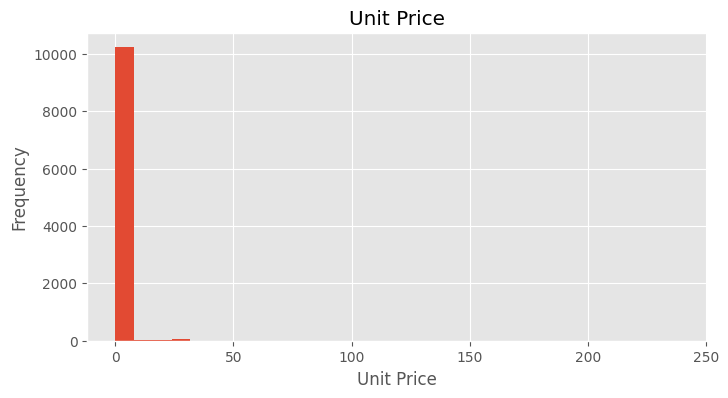

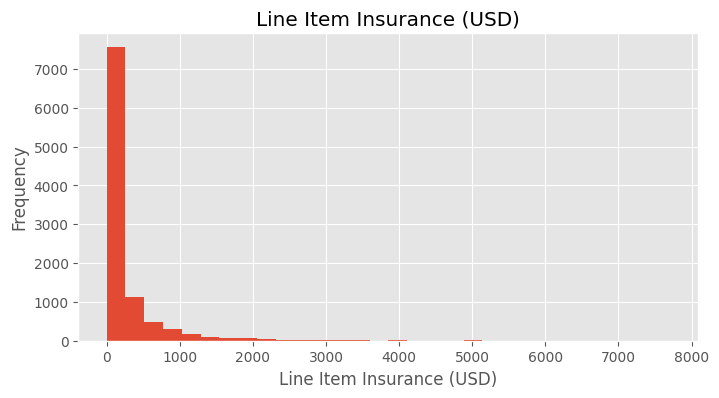

In [ ]:
#Distribution of Every Numeric Column
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:

    plt.figure(figsize=(8,4))

    plt.hist(df[col].dropna(), bins=30)

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()